In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [5]:
spam_df = pd.read_csv("spam.csv",encoding="ISO-8859-1")

In [7]:
spam_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [10]:
spam_df.info()
spam_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [11]:
spam_df.drop(
    columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"],
    inplace = True
)

In [14]:
spam_df.rename(
    columns = {
        "v1" : "Target",
        "v2" : "Message"
    },
    inplace = True
)

In [16]:
spam_df.head()

,Target,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
spam_df.duplicated().sum()

np.int64(0)

In [20]:
spam_df.drop_duplicates(inplace=True)

In [24]:
spam_df["Target"] = spam_df["Target"].map({
    "ham" : 0,
    "spam" : 1
})

<Axes: xlabel='Target', ylabel='count'>

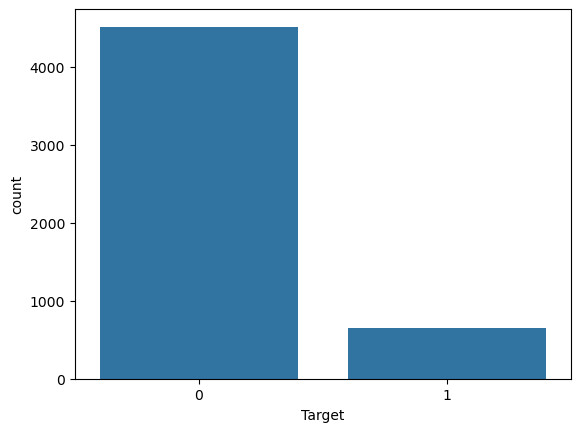

In [26]:
sns.countplot(
    data = spam_df,
    x="Target"
)

In [27]:
spam_df["Message_Length"] = spam_df["Message"].apply(len)

<Axes: xlabel='Message_Length', ylabel='Count'>

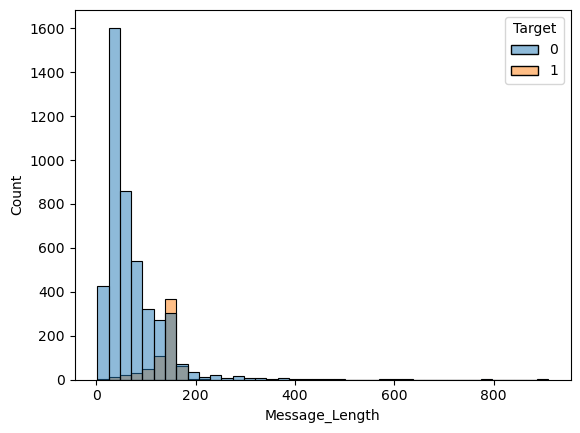

In [35]:
sns.histplot(
    data = spam_df,
    x = "Message_Length",
    hue = "Target",
    bins = 40
)

In [39]:
X = spam_df["Message"]
y = spam_df["Target"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
vectorizer = CountVectorizer()

In [45]:
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [46]:
print(X_train_vectorized.shape)
print(X_test_vectorized.shape)

(4135, 7657)
(1034, 7657)


In [48]:
model = MultinomialNB()
model.fit(X_train_vectorized,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [49]:
y_pred = model.predict(X_test_vectorized)

In [50]:
y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [51]:
y_test

1617    0
2064    0
1272    0
3020    0
3642    0
       ..
4146    0
1208    0
4795    1
3575    0
2820    0
Name: Target, Length: 1034, dtype: int64

In [61]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

precision = precision_score(y_test, y_pred)
print("Precision :", precision)

recall = recall_score(y_test, y_pred)
print("Recall :", recall)

f1 = f1_score(y_test, y_pred)
print("F1 Score :", f1)

print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy : 0.9854932301740812
Precision : 0.9850746268656716
Recall : 0.9103448275862069
F1 Score : 0.946236559139785
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       889
           1       0.99      0.91      0.95       145

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034

[[887   2]
 [ 13 132]]


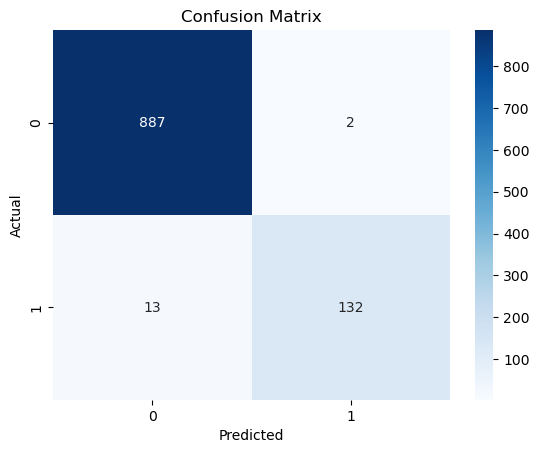

In [63]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()